# Custom Pipeline — From Simulation to Analysis

This notebook is a **complete, step-by-step walkthrough** of how to use the
NeuralRNN framework for your own research. By the end, you will know how to
take any custom dataset, build or define an RNN model, train it, and run a
full dynamical systems analysis.

**What you'll learn in each section:**

| Section | What you'll do |
|---------|---------------|
| **1. Dataset** | Construct a simulation dataset with oscillatory dynamics (input-dependent frequency) |
| **2. Data Import** | Import your data via `CustomDataset` — the universal data entry point |
| **3. Model** | Build a CTRNN using the `AutoConfig` / `AutoModel` factory |
| **4. Training** | Save/load models, configure the `Objective` system, train with the unified `Trainer` |
| **5. Analysis** | Full pipeline: I/O evaluation, 3D PCA, per-condition vector fields, fixed points, eigenvalues |
| **6. Custom Model** | Define a new RNN from scratch, train it, and compare with the CTRNN |

**The Task:** A 1D constant input (0.2 or 0.4) appears after a variable delay.
The RNN must produce a sinusoidal output whose **frequency equals the input value × 10 Hz**
(0.2 → 2 Hz, 0.4 → 4 Hz). This is a nontrivial dynamical task — the network must
internally generate oscillations at a frequency controlled by the input amplitude.

> **Reference:** This notebook follows the style and analysis patterns from
> `02_ctrnn_fixedpoints_paradigmA.ipynb`. All analysis tools are **model-agnostic**
> — they work with any model implementing `recurrence` and `readout`.

## 0. Setup

In [1]:
# if not pip install, uncomment the following lines to add the src directory to the path
# import sys
# sys.path.append('../src')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.lines import Line2D
from IPython.display import HTML
import os
from pathlib import Path

from neuralrnn import (
    AutoConfig, AutoModel,
    Trainer, TrainingArguments,
    SupervisedObjective,
    NeuralDynamicsModel, DynamicsModelOutput,
    NeuralRNNConfig,
)
from neuralrnn.auto.modeling_auto import register_model
from neuralrnn.data.custom_dataset import CustomDataset
from neuralrnn.analysis import (
    fit_pca, collect_states,
    find_fixed_points, linearize, dominant_direction,
    compute_vector_field,
)
from neuralrnn import visualization as viz

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Trained checkpoints and generated figures live next to this notebook
MODEL_DIR = Path("./models/03")
FIG_DIR = Path("./figs/03")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

Using device: cuda


---
## 1. Constructing a Custom Simulation Dataset

### 1.1 Task description

We design an **oscillatory frequency-control task** from scratch. This mimics a
real experimental scenario where you have trial-structured data with different
conditions and want to train an RNN.

**Key design decisions:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Input dimension | 1 | A single control signal determines the oscillation frequency |
| Output dimension | 1 | A single sine-wave output |
| Sampling rate | 100 Hz | Standard for neurophysiological recordings |
| Trial duration | 5 s (500 samples) | Long enough for multiple oscillation cycles |
| Onset variability | 1.0–2.0 s (uniform) | Prevents the network from memorizing a fixed onset |
| Number of trials | 200 | Sufficient for training a small RNN |
| Conditions | 2 (2 Hz, 4 Hz) | Tests whether the network can produce different frequencies |
| Frequency mapping | input × 10 = Hz | 0.2 → 2 Hz, 0.4 → 4 Hz; input amplitude directly encodes frequency |

**Why oscillatory dynamics?** Oscillations are a fundamental feature of neural
circuits. An RNN that can produce input-dependent oscillations has learned to
generate a **limit cycle** — a closed orbit in state space. This is more
challenging than a fixed-point attractor and serves as an excellent test case
for dynamical systems analysis.

### 1.2 Generating the simulation data

Below we construct all 200 trials. For each trial:
1. Choose a condition (input = 0.2 or 0.4, balanced across trials)
2. Randomly sample an onset time between 1.0 and 2.0 seconds
3. Build the 1D input signal (0 before onset, constant level after)
4. Build the 1D target output (0 before onset, sine wave after)

The sine wave starts at phase 0 (sin(0) = 0) at the onset sample, ensuring
a smooth transition from the pre-onset silence.

In [2]:
# =========================================================================
# 1.2 Generate the simulation dataset
# =========================================================================

# --- Task parameters ---
FS = 100                      # Sampling frequency (Hz)
TRIAL_DUR = 5.0               # Trial duration (seconds)
N_POINTS = int(FS * TRIAL_DUR)  # 500 time points per trial
N_TRIALS = 200                # Total number of trials

ONSET_MIN = 1.0               # Earliest onset (seconds)
ONSET_MAX = 2.0               # Latest onset (seconds)

# Condition definitions
#   condition 0: input=0.2 → freq=2.0 Hz
#   condition 1: input=0.4 → freq=4.0 Hz
# The mapping is: frequency (Hz) = input_level × 10
CONDITIONS = [
    {"name": "2 Hz",  "input_level": 0.2, "freq": 2.0, "n_trials": N_TRIALS // 2},
    {"name": "4 Hz",  "input_level": 0.4, "freq": 4.0, "n_trials": N_TRIALS // 2},
]

rng = np.random.RandomState(42)

inputs_all = []        # Will store (n_points,) arrays
outputs_all = []       # Will store (n_points,) arrays
conditions_all = []    # 0 or 1
onset_samples = []     # onset position (in samples)

for cond_idx, cond in enumerate(CONDITIONS):
    input_level = cond["input_level"]
    freq = cond["freq"]

    for _ in range(cond["n_trials"]):
        # --- Random onset ---
        onset_sec = rng.uniform(ONSET_MIN, ONSET_MAX)
        onset_samp = int(onset_sec * FS)
        onset_samples.append(onset_samp)

        # --- Input signal: 0 → constant level at onset ---
        inp = np.zeros(N_POINTS, dtype=np.float32)
        inp[onset_samp:] = input_level

        # --- Output signal: sine wave starting at onset, phase 0 ---
        out = np.zeros(N_POINTS, dtype=np.float32)
        n_post_onset = N_POINTS - onset_samp
        t_post = np.arange(n_post_onset) / FS           # time from onset (seconds)
        out[onset_samp:] = np.sin(2 * np.pi * freq * t_post)

        inputs_all.append(inp)
        outputs_all.append(out)
        conditions_all.append(cond_idx)

# Stack into arrays
inputs_all = np.stack(inputs_all)        # (200, 500)
outputs_all = np.stack(outputs_all)      # (200, 500)
conditions_all = np.array(conditions_all)
onset_samples = np.array(onset_samples)

print(f"Inputs shape:    {inputs_all.shape}   (n_trials={N_TRIALS}, T={N_POINTS})")
print(f"Outputs shape:   {outputs_all.shape}")
print(f"Conditions: {np.sum(conditions_all == 0)} x 2 Hz, "
      f"{np.sum(conditions_all == 1)} x 4 Hz")
print(f"Onset range: {onset_samples.min()}-{onset_samples.max()} samples "
      f"({onset_samples.min()/FS:.2f}-{onset_samples.max()/FS:.2f} s)")
print(f"\nFirst trial, onset sample = {onset_samples[0]}:")
print(f"  input[{onset_samples[0]-1}]  = {inputs_all[0, onset_samples[0]-1]:.2f}  (before onset)")
print(f"  input[{onset_samples[0]}]    = {inputs_all[0, onset_samples[0]]:.2f}  (at onset)")
print(f"  output[{onset_samples[0]}]   = {outputs_all[0, onset_samples[0]]:.4f}  (sin(0)=0)")
print(f"  output[{onset_samples[0]+25}] = {outputs_all[0, onset_samples[0]+25]:.4f}  (1/4 cycle)")

Inputs shape:    (200, 500)   (n_trials=200, T=500)
Outputs shape:   (200, 500)
Conditions: 100 x 2 Hz, 100 x 4 Hz
Onset range: 100-198 samples (1.00-1.98 s)

First trial, onset sample = 137:
  input[136]  = 0.00  (before onset)
  input[137]    = 0.20  (at onset)
  output[137]   = 0.0000  (sin(0)=0)
  output[162] = 0.0000  (1/4 cycle)


### 1.3 Visualizing sample trials

We plot **both input and output** for several trials from each condition.
The dashed vertical line marks the onset time.

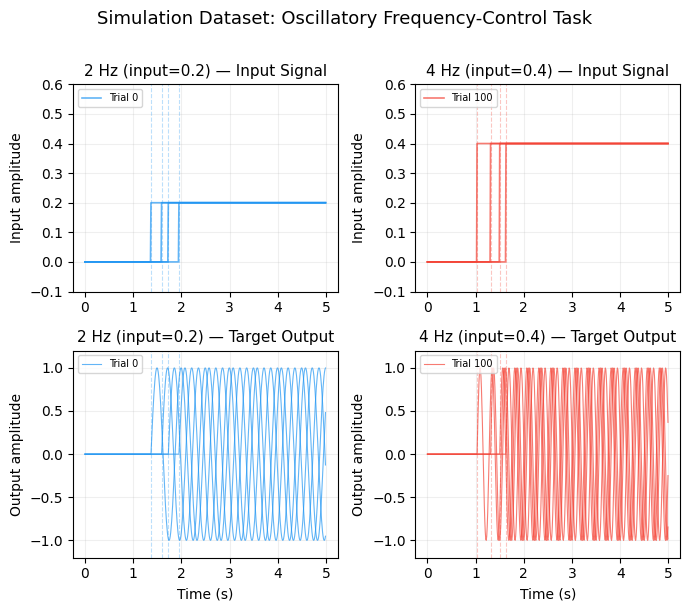

In [31]:
# --- Visualization: 4 trials per condition ---
n_show_per_cond = 4
cond_colors = ['#2196F3', '#F44336']  # blue = 2 Hz, red = 4 Hz
cond_names = ['2 Hz (input=0.2)', '4 Hz (input=0.4)']

fig, axes = plt.subplots(2, 2, figsize=(7, 6))

for cond_idx in [0, 1]:
    trial_indices = np.where(conditions_all == cond_idx)[0][:n_show_per_cond]

    for i, trial_idx in enumerate(trial_indices):
        t = np.arange(N_POINTS) / FS
        onset_s = onset_samples[trial_idx] / FS
        color = cond_colors[cond_idx]

        # Top row: Input
        ax = axes[0, cond_idx]
        ax.plot(t, inputs_all[trial_idx], color=color, alpha=0.7, lw=1.2,
                label=f'Trial {trial_idx}' if i == 0 else None)
        ax.axvline(x=onset_s, color=color, linestyle='--', alpha=0.3, lw=0.8)

        # Bottom row: Output
        ax = axes[1, cond_idx]
        ax.plot(t, outputs_all[trial_idx], color=color, alpha=0.7, lw=0.8,
                label=f'Trial {trial_idx}' if i == 0 else None)
        ax.axvline(x=onset_s, color=color, linestyle='--', alpha=0.3, lw=0.8)

for col, cond_name in enumerate(cond_names):
    axes[0, col].set_title(f'{cond_name} — Input Signal', fontsize=11)
    axes[0, col].set_ylabel('Input amplitude')
    axes[0, col].set_ylim(-0.1, 0.6)
    axes[0, col].legend(fontsize=7, loc='upper left')
    axes[0, col].grid(True, alpha=0.2)

    axes[1, col].set_title(f'{cond_name} — Target Output', fontsize=11)
    axes[1, col].set_ylabel('Output amplitude')
    axes[1, col].set_xlabel('Time (s)')
    axes[1, col].set_ylim(-1.2, 1.2)
    axes[1, col].legend(fontsize=7, loc='upper left')
    axes[1, col].grid(True, alpha=0.2)

fig.suptitle('Simulation Dataset: Oscillatory Frequency-Control Task',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "dataset_sample_trials.png", dpi=150)
plt.show()

---
## 2. Importing Data into the NeuralRNN Framework

`CustomDataset` is the **universal data entry point** for user-generated data.
It accepts numpy arrays, torch tensors, `.npz` files, `.mat` files, or plain dicts.

### Key convention: batch-first `(trials, time, features)`

NeuralRNN uses the **batch-first** convention throughout:
- **Inputs**: `(batch_size, time_steps, input_dim)`
- **Targets**: `(batch_size, time_steps, output_dim)`

Our data is already in `(n_trials, n_points)` format — we just need to add the
**feature dimension** to make it `(n_trials, n_points, 1)`.

In [5]:
# Add feature dimension: (n_trials, n_points) → (n_trials, n_points, 1)
inputs_3d = inputs_all[:, :, np.newaxis]     # (200, 500, 1)
outputs_3d = outputs_all[:, :, np.newaxis]   # (200, 500, 1)

print(f"Inputs:  {inputs_3d.shape}   ← (n_trials, T, input_dim=1)")
print(f"Outputs: {outputs_3d.shape}  ← (n_trials, T, output_dim=1)")

# Create the CustomDataset
dataset = CustomDataset.from_arrays(
    inputs=inputs_3d,
    targets=outputs_3d,
    mode="supervised",       # Paradigm A: input-output supervised learning
    batch_size=16,
    normalize=False,          # Our data is already well-scaled
    test_fraction=0.2,        # 20% held out for testing
    seed=42,
)

print(f"\nDataset summary:")
print(f"  Mode:            {dataset.mode}")
print(f"  Input dim:       {dataset.input_dim}")
print(f"  Output dim:      {dataset.output_dim}")
print(f"  Train trials:    {len(dataset)}")
print(f"  Test trials:     {len(dataset.test_set) if dataset.test_set else 0}")

Inputs:  (200, 500, 1)   ← (n_trials, T, input_dim=1)
Outputs: (200, 500, 1)  ← (n_trials, T, output_dim=1)

Dataset summary:
  Mode:            supervised
  Input dim:       1
  Output dim:      1
  Train trials:    160
  Test trials:     40


In [6]:
# Inspect a batch to verify the data format
batch = dataset.sample_batch()
print("Batch keys:", list(batch.keys()))
for k, v in batch.items():
    if v is not None:
        print(f"  {k:10s}: shape={tuple(v.shape)}, dtype={v.dtype}")
    else:
        print(f"  {k:10s}: None")

print(f"\nOther import options:")
print(f"  CustomDataset.from_npz('data.npz')")
print(f"  CustomDataset.from_mat('data.mat')")
print(f"  CustomDataset.from_dict({{'inputs': ..., 'targets': ...}})")

Batch keys: ['inputs', 'targets', 'mask']
  inputs    : shape=(16, 500, 1), dtype=torch.float32
  targets   : shape=(16, 500, 1), dtype=torch.float32
  mask      : shape=(16, 500), dtype=torch.float32

Other import options:
  CustomDataset.from_npz('data.npz')
  CustomDataset.from_mat('data.mat')
  CustomDataset.from_dict({'inputs': ..., 'targets': ...})


---
## 3. Building the Model

NeuralRNN follows the **transformers-like `AutoConfig` / `AutoModel` pattern**:
```python
config = AutoConfig.for_model("family", **hyperparams)
model = AutoModel.from_config(config)
model.save_pretrained("path/")
model = AutoModel.from_pretrained("path/")
```

We use the **CTRNN** (Continuous-Time RNN), a standard model for cognitive
task optimization. Its dynamics follow:

$$z_{t+1} = (1-\alpha)z_t + \alpha \cdot f(W_{rec} z_t + W_{in} x_t + b)$$

where $\alpha = dt/\tau$ controls the timescale and $f$ is the activation function.

> **Note:** Section 6 demonstrates how to define a **custom RNN architecture**
> from scratch and compare it against the CTRNN.

In [7]:
# Build a CTRNN for our 1D->1D oscillatory task
config = AutoConfig.for_model(
    "ctrnn",
    input_dim=dataset.input_dim,     # 1  — single control signal
    latent_dim=64,                    # 64 — hidden units; enough for oscillations
    output_dim=dataset.output_dim,    # 1  — scalar sine-wave output
    dt=1.0,                           # Euler step (1.0 = no scaling; data is at 100 Hz)
    tau=10.0,                         # Time constant (smaller = faster decay)
    activation="relu",               # ReLU activation (sparse, biologically plausible)
    trainable_h0=False,               # Fixed zero initial state
    sigma_rec=0.0,                    # No recurrent noise
)

model = AutoModel.from_config(config)
print(f"Model type:    {type(model).__name__}")
print(f"Total params:  {model.num_parameters():,}")
print(f"\nConfiguration:")
print(config)

Model type:    CTRNNModel
Total params:  4,353

Configuration:
CTRNNConfig({
  "activation": "relu",
  "alpha": 0.1,
  "dale": false,
  "dale_signs": null,
  "dt": 1.0,
  "ei_ratio": 0.8,
  "freeze_h0": false,
  "freeze_input": false,
  "freeze_output": false,
  "freeze_recurrent": false,
  "input_dim": 1,
  "latent_dim": 64,
  "model_type": "ctrnn",
  "noise_alpha_scaling": false,
  "nonlinearity_mode": "pre_activation",
  "output_dim": 1,
  "sigma_rec": 0.0,
  "tau": 10.0,
  "trainable_h0": false
})


---
## 4. Training

### 4a. Model Persistence — Save & Load

NeuralRNN uses the same persistence API as HuggingFace transformers.
We **first try to load a previously trained model** to avoid retraining.
If no saved model exists, we train from scratch.

The save format: `config.json` + `model.safetensors` in a directory.

In [8]:
# ---- Try to load a previously trained model ----
SAVE_DIR = "./models/03/ctrnn_oscillatory"
model_loaded_from_disk = False

if os.path.exists(SAVE_DIR) and os.path.exists(os.path.join(SAVE_DIR, "model.safetensors")):
    print(f"Found saved model at {SAVE_DIR}/")
    model = AutoModel.from_pretrained(SAVE_DIR)
    model.to(device)
    model_loaded_from_disk = True
    print(f"  Loaded: {type(model).__name__}, {model.num_parameters():,} params")
else:
    print(f"No saved model found at {SAVE_DIR}/")
    print("  Will train from scratch and save afterwards.")

Found saved model at ./models/03/ctrnn_oscillatory/
  Loaded: CTRNNModel, 4,353 params


### 4b. Understanding the Objective System

NeuralRNN's `Trainer` is **paradigm-agnostic**: it calls `dataset.sample_batch()`,
feeds data to `model.forward()`, and minimizes the loss from the `Objective`.
**The paradigm (A vs B) is determined entirely by which Objective you choose.**

| Objective | Paradigm | Use Case | Loss Function | Key Parameter |
|-----------|----------|----------|---------------|---------------|
| `SupervisedObjective("regression")` | A | Continuous output | MSE | `task_type="regression"` |
| `SupervisedObjective("classification")` | A | Discrete choice tasks | Cross-Entropy | `task_type="classification"` |
| `TeacherForcingObjective(alpha=0.1)` | B | Reconstruct observed dynamics | MSE + α·‖z−ẑ‖² | `alpha` |
| `BehavioralObjective()` | A | Fit choice behavior only | NLL of choices | model-specific |

**How to choose:**
- **Continuous output** (sine wave, motor trajectory) → `"regression"`
- **Discrete choices** (decision-making tasks) → `"classification"`
- **Observed trajectories** (neural data) → `TeacherForcingObjective`

We use `SupervisedObjective(task_type="regression")` because our output is a
continuous sine wave.

In [9]:
# ---- Set up the Objective ----
objective = SupervisedObjective(task_type="regression")
print(f"Objective:  {type(objective).__name__}")
print(f"Task type:  {objective.task_type}")
print(f"Loss:       Mean Squared Error (MSE)")

# ---- Training configuration ----
args = TrainingArguments(
    learning_rate=1e-3,
    max_steps=3000,
    batch_size=16,
    grad_clip_norm=1.0,
    optimizer="adam",
    log_every=200,
    device=device,
    seed=42,
)

print(f"\nTraining configuration:")
for key in ['learning_rate', 'max_steps', 'batch_size', 'grad_clip_norm',
            'optimizer', 'device']:
    print(f"  {key:20s}: {getattr(args, key)}")

Objective:  SupervisedObjective
Task type:  regression
Loss:       Mean Squared Error (MSE)

Training configuration:
  learning_rate       : 0.001
  max_steps           : 3000
  batch_size          : 16
  grad_clip_norm      : 1.0
  optimizer           : adam
  device              : cuda


### 4c. Running Training

In [10]:
if not model_loaded_from_disk:
    trainer = Trainer(
        model=model,
        dataset=dataset,
        objective=objective,
        args=args,
    )

    print("Training CTRNN on oscillatory frequency-control task...")
    history = trainer.train()

    # Save the trained model
    os.makedirs(SAVE_DIR, exist_ok=True)
    model.save_pretrained(SAVE_DIR)
    print(f"\nModel saved to {SAVE_DIR}/")
else:
    print("Skipping training — using loaded model.")
    # Create a dummy history for the loss plot
    history = []

Skipping training — using loaded model.


In [11]:
# ---- Plot training loss (if trained) ----
if len(history) > 0:
    steps = [h["step"] for h in history]
    losses = [h["loss"] for h in history]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(steps, losses, linewidth=1.5, color='steelblue')
    ax.set_xlabel("Training Step")
    ax.set_ylabel("MSE Loss")
    ax.set_title("Training Loss — CTRNN on Oscillatory Frequency-Control Task")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

    final_loss = losses[-1]
    initial_loss = losses[0]
    ax.annotate(f"Start: {initial_loss:.4f}",
                xy=(steps[0], initial_loss),
                xytext=(steps[-1] * 0.05, initial_loss * 1.5),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
    ax.annotate(f"Final: {final_loss:.4f}",
                xy=(steps[-1], final_loss),
                xytext=(steps[-1] * 0.65, final_loss * 1.8),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "training_loss_ctrnn.png", dpi=150)
    plt.show()
    print(f"Loss: {initial_loss:.4f} -> {final_loss:.4f} "
          f"({(1 - final_loss/initial_loss)*100:.1f}% reduction)")
else:
    print("No training history available (loaded from disk).")

No training history available (loaded from disk).


---
## 5. Comprehensive Dynamical Systems Analysis

Now we run the full analysis pipeline. All tools are **model-agnostic** — they
work through the `recurrence`/`readout` contract and never import specific model
classes. This means you can use the exact same analysis code with any custom model.

**Analysis roadmap:**
1. **Input-Output evaluation** — does the model produce the right output?
2. **3D PCA trajectories** — global view of hidden state geometry
3. **Per-condition 2D Vector fields** — the flow geometry of the learned oscillations
4. **Per-condition Fixed points** — attractors under each input condition
5. **Eigenvalues** — local stability and oscillatory modes

### 5a. Model Input, Output, and Internal State Visualization

Before diving into dynamical systems analysis, we first check the basics:
given a test input, does the model produce the expected output? We plot **both
the input and the output** for several test trials, overlaid with the ground truth.

**What this tells you:**
- Does the model correctly detect the onset?
- Does it produce the right oscillation frequency?
- Are there systematic errors (phase shifts, amplitude errors, missed onsets)?

In [12]:
model.eval()

# Get test data
test_ds = dataset.test_set
test_inputs = test_ds.X   # (n_test, 500, 1)
test_targets = test_ds.Y  # (n_test, 500, 1)

print(f"Test set: {test_inputs.shape[0]} trials")

# Run model on all test trials at once
with torch.no_grad():
    out = model(test_inputs.to(device))
    preds = out.outputs.cpu().numpy()  # (n_test, 500, 1)
    states = out.states.cpu().numpy()  # (n_test, 500, 64)

# Reconstruct condition labels for the test set
# CustomDataset used seed=42, test_fraction=0.2 — reproduce the split
rng_split = np.random.RandomState(42)
n_test = max(1, int(N_TRIALS * 0.2))
perm = rng_split.permutation(N_TRIALS)
test_indices = np.sort(perm[:n_test])
test_conditions = conditions_all[test_indices]
test_onsets = onset_samples[test_indices]

print(f"Test conditions: {np.sum(test_conditions == 0)} x 2 Hz, "
      f"{np.sum(test_conditions == 1)} x 4 Hz")

Test set: 40 trials
Test conditions: 21 x 2 Hz, 19 x 4 Hz


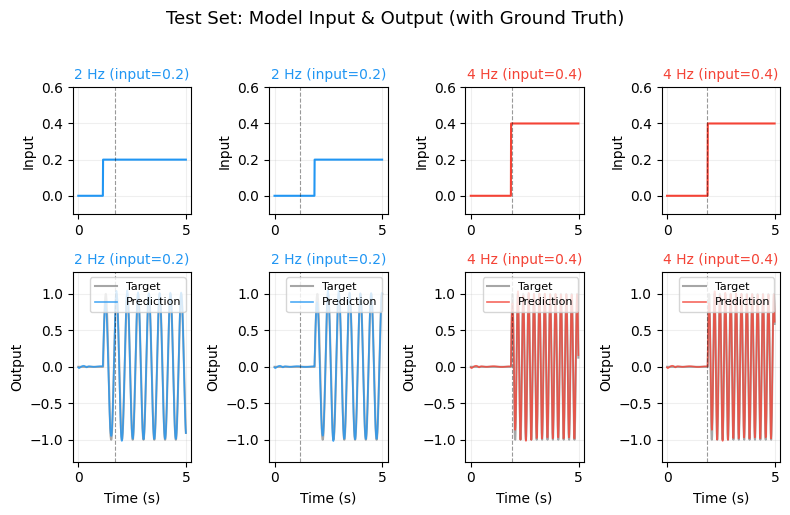

In [33]:
# ---- Plot input + output for sample test trials ----
n_show = 4  # 2 trials per condition
fig, axes = plt.subplots(2, n_show, figsize=(8, 5),
                          gridspec_kw={'height_ratios': [1, 1.5]})

plot_idx = 0
for cond_idx in [0, 1]:
    cond_mask = test_conditions == cond_idx
    cond_trials = np.where(cond_mask)[0][:2]

    for trial_idx in cond_trials:
        t = np.arange(N_POINTS) / FS
        onset_s = test_onsets[trial_idx] / FS

        # === Top: INPUT signal ===
        ax_in = axes[0, plot_idx]
        ax_in.plot(t, test_inputs[trial_idx, :, 0].numpy(),
                   color=cond_colors[cond_idx], lw=1.5)
        ax_in.axvline(x=onset_s, color='black', linestyle='--', alpha=0.4, lw=0.8)
        ax_in.set_title(f'{cond_names[cond_idx]}',
                        fontsize=10, color=cond_colors[cond_idx])
        ax_in.set_ylabel('Input')
        ax_in.set_ylim(-0.1, 0.6)
        ax_in.grid(True, alpha=0.2)

        # === Bottom: OUTPUT (prediction vs target) ===
        ax_out = axes[1, plot_idx]
        ax_out.plot(t, test_targets[trial_idx, :, 0].numpy(),
                    color='gray', lw=1.5, alpha=0.7, label='Target')
        ax_out.plot(t, preds[trial_idx, :, 0],
                    color=cond_colors[cond_idx], lw=1.2, alpha=0.8,
                    label='Prediction')
        ax_out.axvline(x=onset_s, color='black', linestyle='--', alpha=0.4, lw=0.8)
        ax_out.set_title(f'{cond_names[cond_idx]}',
                         fontsize=10, color=cond_colors[cond_idx])
        ax_out.set_xlabel('Time (s)')
        ax_out.set_ylabel('Output')
        ax_out.set_ylim(-1.3, 1.3)
        ax_out.legend(fontsize=8, loc='upper right')
        ax_out.grid(True, alpha=0.2)

        plot_idx += 1

fig.suptitle('Test Set: Model Input & Output (with Ground Truth)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "test_input_output.png", dpi=150)
plt.show()

In [14]:
# ---- Compute per-condition test MSE ----
for cond_idx in [0, 1]:
    cond_mask = test_conditions == cond_idx
    mse = np.mean((preds[cond_mask] - test_targets[cond_mask].numpy()) ** 2)
    print(f"Test MSE ({cond_names[cond_idx]}): {mse:.6f}")

overall_mse = np.mean((preds - test_targets.numpy()) ** 2)
print(f"Test MSE (overall):              {overall_mse:.6f}")

Test MSE (2 Hz (input=0.2)): 0.001426
Test MSE (4 Hz (input=0.4)): 0.001571
Test MSE (overall):              0.001495


### 5b. 3D PCA Trajectory Visualization

We project the 64D latent state trajectories onto the first 3 principal components
to see the **global geometry** of the hidden state dynamics. This PCA is fit on
all test trial states (both conditions, all time steps) to show how the two
conditions relate to each other in the full state space.

**What to look for:**
- **Condition separation**: Blue and red trajectories should occupy different regions
- **Onset dynamics**: Trajectories start near the origin, then diverge after onset
- **Limit cycles**: Oscillations appear as closed loops in the reduced space

Two animation types are provided: **rotation** (camera orbits the 3D plot)
and **progression** (trajectories grow frame-by-frame to show temporal evolution).

In [15]:
# Prepare trajectories — use a subset for clarity (20 per condition)
n_per_cond = 20
plot_trajs = []
plot_colors = []
for cond_idx in [0, 1]:
    cond_mask = test_conditions == cond_idx
    indices = np.where(cond_mask)[0][:n_per_cond]
    for idx in indices:
        plot_trajs.append(states[idx])
        plot_colors.append(cond_colors[cond_idx])

print(f"Plotting {len(plot_trajs)} trajectories ({n_per_cond} per condition)")

Plotting 39 trajectories (20 per condition)


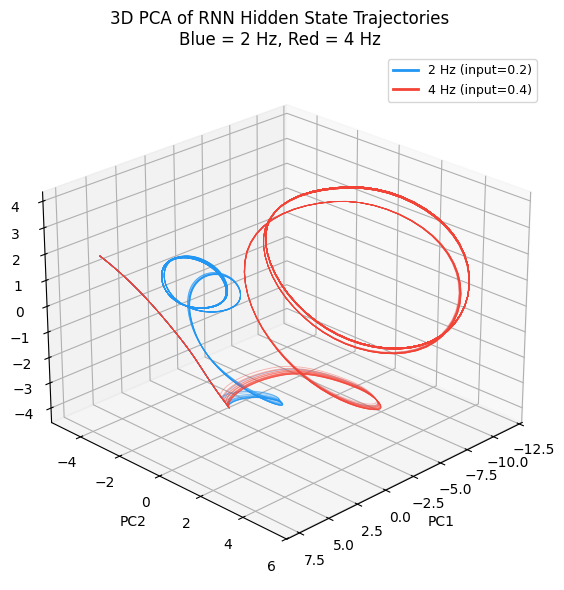

In [16]:
# ---- 3D PCA trajectories (static view) ----
fig, ax = viz.plot_trajectories_3d(
    plot_trajs,
    colors=plot_colors,
    alpha=0.4,
    linewidth=0.6,
    elev=25,
    azim=45,
)
ax.set_title('3D PCA of RNN Hidden State Trajectories\n'
             'Blue = 2 Hz, Red = 4 Hz', fontsize=12)
legend_elements = [
    Line2D([0], [0], color=cond_colors[0], lw=2, label=cond_names[0]),
    Line2D([0], [0], color=cond_colors[1], lw=2, label=cond_names[1]),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_trajectories_3d.png", dpi=150)
plt.show()

You can also plot 3D rotating animation or trajectory progression animation by:
```python
# ---- 3D Rotating Animation ----
print("Creating 3D rotation animation...")
anim_rot = viz.animate_trajectories_3d(
    [plot_trajs[0], plot_trajs[21]],  # Use a subset for smoother animation
    colors=[plot_colors[0], plot_colors[21]],
    fps=20,
    duration=6.0,
    elev=25,
    step=3,
    figsize=(7, 7),
)
html_rot = animation.Animation.to_jshtml(anim_rot)
html_rot = html_rot.replace('animation_mode=once', 'animation_mode=loop')
HTML(html_rot)
```

and 

```python
# ---- Trajectory Progression Animation (3D) ----
print("Creating trajectory progression animation...")
anim_prog = viz.animate_trajectory_progression(
    [plot_trajs[0], plot_trajs[22]],
    colors=[plot_colors[0], plot_colors[21]],
    projection="3d",
    fps=30,
    n_frames=200,
    elev=25,
    azim=45,
    linewidth=1.0,
    alpha=0.8,
    trail_alpha=0.15,
    figsize=(8, 8),
)
html_prog = animation.Animation.to_jshtml(anim_prog)
html_prog = html_prog.replace('animation_mode=once', 'animation_mode=loop')
HTML(html_prog)
```

### 5c. Per-Condition 2D Vector Field Analysis

The **vector field** shows the one-step displacement $F(z) - z$ at every point
in a 2D projection of the state space. This reveals the **flow geometry**.

#### Why per-condition?

The global PCA (Section 5b) is dominated by the **condition-level embedding
differences** and **onset transients** — not the oscillatory limit cycles
themselves. To visualize the limit cycles, we need to:

1. **Separate by condition** — fit PCA only on that condition's post-onset activity
2. **Start from onset** — use only time points after the onset, where the
   oscillation is active
3. **Use the correct task input** — `[0.2]` for the 2 Hz condition, `[0.4]` for 4 Hz

This way, the PC1-PC2 plane captures the **oscillatory manifold** for each
frequency, and the vector field reveals the circular flow of the limit cycle.

In [19]:
# =====================================================================
# Per-condition PCA + Vector field
# =====================================================================

# Collect post-onset states separately for each condition
cond_states_post_onset = {}  # cond_idx -> numpy array (N_post, M)
cond_trajs_post_onset = {}   # cond_idx -> list of (T_post, M) arrays

for cond_idx in [0, 1]:
    cond_mask = test_conditions == cond_idx
    trial_indices = np.where(cond_mask)[0]

    trajs = []
    for idx in trial_indices:
        delay = 100
        onset_samp = test_onsets[idx] + delay
        # Only use time points from onset onwards (oscillation period)
        traj_post = states[idx, onset_samp:, :]  # (T_post, M)
        trajs.append(traj_post)

    cond_states_post_onset[cond_idx] = np.concatenate(trajs, axis=0)  # (N_total, M)
    cond_trajs_post_onset[cond_idx] = trajs
    print(f"Condition {cond_idx} ({cond_names[cond_idx]}): "
          f"post-onset states shape = {cond_states_post_onset[cond_idx].shape}, "
          f"({len(trajs)} trials)")

Condition 0 (2 Hz (input=0.2)): post-onset states shape = (5269, 64), (21 trials)
Condition 1 (4 Hz (input=0.4)): post-onset states shape = (4780, 64), (19 trials)


In [20]:
# ---- Fit per-condition 2D PCA and compute vector fields ----
pca_per_cond = {}
vf_per_cond = {}
task_inputs_per_cond = {0: [0.2], 1: [0.4]}  # input per condition

for cond_idx in [0, 1]:
    # Fit PCA on post-onset states for this condition only
    pca_per_cond[cond_idx] = fit_pca(
        cond_states_post_onset[cond_idx], n_components=2)
    print(f"\nCondition {cond_idx} ({cond_names[cond_idx]}):")
    print(f"  PCA explained variance: "
          f"{np.round(pca_per_cond[cond_idx].explained_variance_ratio, 3)}")
    print(f"  Cumulative: "
          f"{pca_per_cond[cond_idx].explained_variance_ratio.sum():.3f}")

    # Compute vector field with the CORRECT task_input for this condition
    task_inp = torch.tensor(task_inputs_per_cond[cond_idx], dtype=torch.float32)
    vf_per_cond[cond_idx] = compute_vector_field(
        model,
        basis=pca_per_cond[cond_idx].components[:2],
        mean=pca_per_cond[cond_idx].mean,
        task_input=task_inp,
        extent=(-5.0, 5.0),
        n_grid=25,
    )
    print(f"  Vector field: {vf_per_cond[cond_idx].grid_pc.shape[0]}x"
          f"{vf_per_cond[cond_idx].grid_pc.shape[1]} grid")


Condition 0 (2 Hz (input=0.2)):
  PCA explained variance: [0.694 0.164]
  Cumulative: 0.857
  Vector field: 25x25 grid

Condition 1 (4 Hz (input=0.4)):
  PCA explained variance: [0.572 0.387]
  Cumulative: 0.959
  Vector field: 25x25 grid


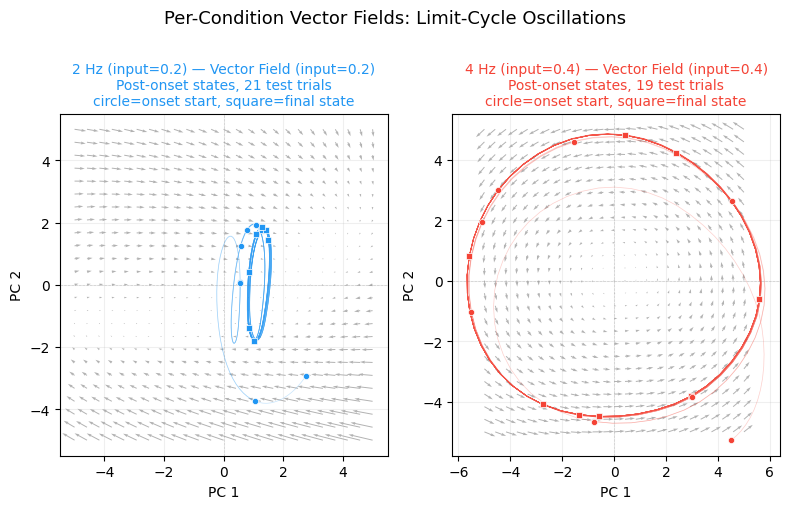

Interpretation:
  - Circular/quiver arrows → flow around a limit cycle
  - The trajectories should form approximately closed loops
  - Different frequencies → different loop sizes/shapes in their respective PCA spaces


In [34]:
# ---- Plot two vector fields side by side (one per condition) ----
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

for cond_idx in [0, 1]:
    ax = axes[cond_idx]
    pca = pca_per_cond[cond_idx]
    vf = vf_per_cond[cond_idx]

    # Plot a few post-onset trajectories
    trajs = cond_trajs_post_onset[cond_idx]
    n_show = min(8, len(trajs))
    for i in range(n_show):
        traj_pc = pca.transform(trajs[i])
        ax.plot(traj_pc[:, 0], traj_pc[:, 1],
                color=cond_colors[cond_idx], alpha=0.25, lw=0.5)
        # Mark start point (onset)
        ax.scatter(traj_pc[0, 0], traj_pc[0, 1],
                   color=cond_colors[cond_idx], s=20, marker='o',
                   edgecolors='white', linewidths=0.5, zorder=3)
        # Mark end point
        ax.scatter(traj_pc[-1, 0], traj_pc[-1, 1],
                   color=cond_colors[cond_idx], s=20, marker='s',
                   edgecolors='white', linewidths=0.5, zorder=3)

    # Vector field (quiver)
    X = vf.grid_pc[:, :, 0]
    Y = vf.grid_pc[:, :, 1]
    U = vf.velocity_pc[:, :, 0]
    V = vf.velocity_pc[:, :, 1]
    ax.quiver(X, Y, U, V, color='gray', scale=None, width=0.003,
              alpha=0.6)

    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_title(f'{cond_names[cond_idx]} — Vector Field (input={task_inputs_per_cond[cond_idx][0]})\n'
                 f'Post-onset states, {len(trajs)} test trials\n'
                 f'circle=onset start, square=final state',
                 fontsize=10, color=cond_colors[cond_idx])
    ax.grid(True, alpha=0.2)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.3)

fig.suptitle('Per-Condition Vector Fields: Limit-Cycle Oscillations',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "vector_fields_per_condition.png", dpi=150)
plt.show()

print("Interpretation:")
print("  - Circular/quiver arrows → flow around a limit cycle")
print("  - The trajectories should form approximately closed loops")
print("  - Different frequencies → different loop sizes/shapes in their respective PCA spaces")

### 5d. Per-Condition Fixed Point Analysis

Fixed points are states $z^*$ where $F(z^*) = z^*$. We find them numerically
by minimizing $\|F(z) - z\|^2$ using gradient descent.

We search **separately for each condition**, using the same per-condition PCA
(from post-onset activity) and the **correct task_input per condition**.

**What to look for:**
- **Stable FP** ($|\lambda_{\max}| < 1$, blue circles): trajectories converge here
- **Unstable FP** ($|\lambda_{\max}| > 1$, red crosses): trajectories diverge
- In an **oscillatory system**, fixed points are typically unstable — the system
  flows away into a limit cycle. The fixed point sits at the **center** of the
  oscillation, and the dominant eigenvector points along the direction of escape.

In [22]:
# ---- Fixed point search per condition with correct task_input ----
fps_per_cond = {}

for cond_idx in [0, 1]:
    task_inp = torch.tensor(task_inputs_per_cond[cond_idx], dtype=torch.float32)
    print(f"Searching fixed points for {cond_names[cond_idx]} "
          f"(input={task_inputs_per_cond[cond_idx][0]})...")

    fps_per_cond[cond_idx] = find_fixed_points(
        model, backend='numeric',
        task_input=task_inp,
        n_candidates=128, n_iters=10000, speed_tol=0.5
    )

    fps = fps_per_cond[cond_idx]
    if len(fps) > 0:
        speeds = [p.speed for p in fps.points]
        stable = sum(1 for p in fps.points if p.is_stable)
        print(f"  Found {len(fps)} fixed points ({stable} stable, "
              f"{len(fps)-stable} unstable)")
        print(f"  Speed range: [{min(speeds):.4f}, {max(speeds):.4f}]")
    else:
        print(f"  No fixed points found.")

Searching fixed points for 2 Hz (input=0.2) (input=0.2)...
  Found 99 fixed points (35 stable, 64 unstable)
  Speed range: [0.0000, 0.0321]
Searching fixed points for 4 Hz (input=0.4) (input=0.4)...
  Found 118 fixed points (6 stable, 112 unstable)
  Speed range: [0.0091, 0.0483]


In [23]:
cond_trajs_post_onset[cond_idx][0].shape

(210, 64)

C:\Users\heiheihei\AppData\Local\Temp\ipykernel_4628\3498925067.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(coords[i, 0], coords[i, 1], marker=marker, c=fp_color,


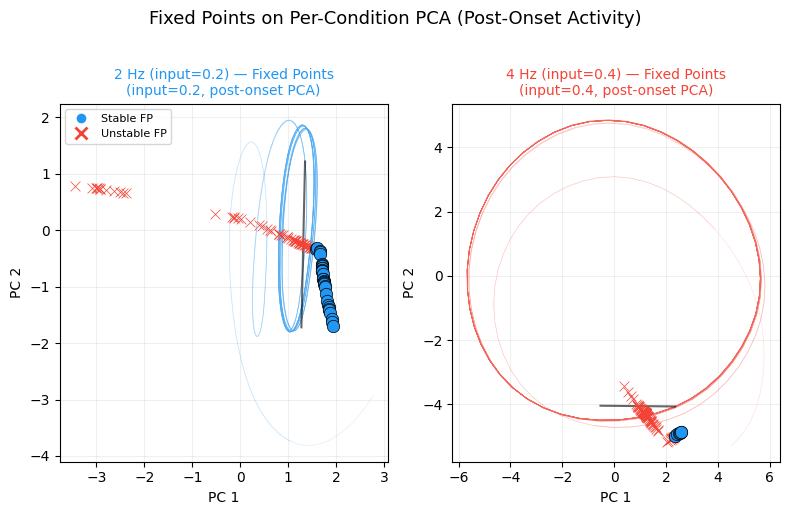

Interpretation:
  - If fixed points are mostly unstable (red x):
    the system is driven into a limit cycle → oscillatory dynamics
  - The dominant eigenvector shows the escape direction from the FP
  - FP at the center of the trajectory cloud = the oscillation center


In [35]:
# ---- Visualize fixed points on per-condition PCA with trajectories ----
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

for cond_idx in [0, 1]:
    ax = axes[cond_idx]
    pca = pca_per_cond[cond_idx]
    fps = fps_per_cond[cond_idx]

    # Background: post-onset trajectories (light)
    trajs = cond_trajs_post_onset[cond_idx]
    n_show = min(10, len(trajs))
    for i in range(n_show):
        traj_pc = pca.transform(trajs[i])
        ax.plot(traj_pc[:, 0], traj_pc[:, 1],
                color=cond_colors[cond_idx], alpha=0.15, lw=0.5)

    # Fixed points
    if len(fps) > 0:
        coords = pca.transform(fps.coords())
        for i, fp in enumerate(fps.points):
            marker = 'o' if fp.is_stable else 'x'
            fp_color = '#2196F3' if fp.is_stable else '#F44336'
            size = 80 if fp.is_stable else 50
            ax.scatter(coords[i, 0], coords[i, 1], marker=marker, c=fp_color,
                      s=size, zorder=10, edgecolors='black', linewidths=0.5)

        # Dominant eigenvector at the best (lowest-speed) fixed point
        best_idx = np.argmin([p.speed for p in fps.points])
        fp_ref = fps.points[best_idx]
        task_inp = torch.tensor(task_inputs_per_cond[cond_idx],
                                dtype=torch.float32)
        lin = linearize(model, fp_ref.z, task_input=task_inp)
        d = dominant_direction(lin)
        end_pts = np.array([fp_ref.z + 2 * d, fp_ref.z - 2 * d])
        seg = pca.transform(end_pts)
        ax.plot(seg[:, 0], seg[:, 1], 'k-', lw=1.5, alpha=0.6,
                label='Dominant eigvec')

    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_title(f'{cond_names[cond_idx]} — Fixed Points\n'
                 f'(input={task_inputs_per_cond[cond_idx][0]}, '
                 f'post-onset PCA)',
                 fontsize=10, color=cond_colors[cond_idx])
    ax.grid(True, alpha=0.2)

# Legend on first panel
legend_el = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3',
           markersize=8, label='Stable FP'),
    Line2D([0], [0], marker='x', color='w', markeredgecolor='#F44336',
           markeredgewidth=2, markersize=8, label='Unstable FP'),
]
axes[0].legend(handles=legend_el, fontsize=8, loc='upper left')

fig.suptitle('Fixed Points on Per-Condition PCA (Post-Onset Activity)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fixed_points_per_condition.png", dpi=150)
plt.show()

print("Interpretation:")
print("  - If fixed points are mostly unstable (red x):")
print("    the system is driven into a limit cycle → oscillatory dynamics")
print("  - The dominant eigenvector shows the escape direction from the FP")
print("  - FP at the center of the trajectory cloud = the oscillation center")

### 5e. Jacobian Eigenvalue Analysis

The eigenvalues $\lambda_i$ of the Jacobian $\partial F / \partial z$ at a fixed
point characterize the **local stability and dynamics**.

| Eigenvalue property | Dynamical interpretation |
|--------------------|-------------------------|
| $\|\lambda\| < 1$ | **Stable direction** — perturbations decay |
| $\|\lambda\| > 1$ | **Unstable direction** — perturbations grow |
| Complex conjugate pair, $\|\lambda\| \approx 1$ | **Oscillatory mode** — rotational dynamics |
| $\lambda$ real, $< 0$ | **Flip mode** — alternates sign each step |

For our oscillatory task, we expect **complex conjugate eigenvalue pairs**
with magnitude near or above 1 — these drive the rotational dynamics
that generate the limit cycle.

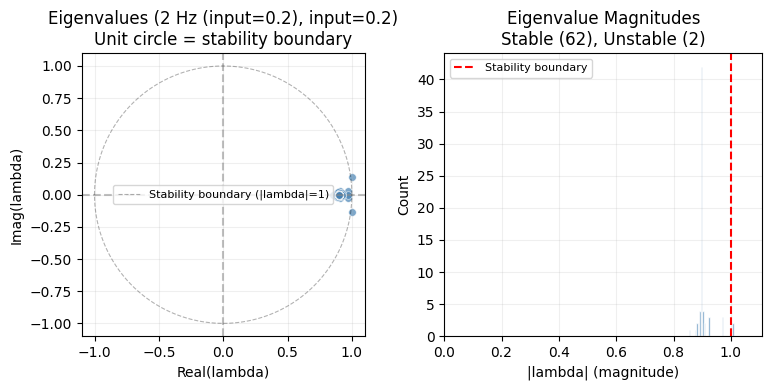

Fixed point speed: 0.000015

Top 8 eigenvalues by magnitude:
  #1: lambda = +1.0003+0.1335j  |lambda|=1.0092  <-- OSCILLATORY & UNSTABLE (limit cycle driver)
  #2: lambda = +1.0003-0.1335j  |lambda|=1.0092  <-- OSCILLATORY & UNSTABLE (limit cycle driver)
  #3: lambda = +0.9691+0.0285j  |lambda|=0.9695  (oscillatory pair)
  #4: lambda = +0.9691-0.0285j  |lambda|=0.9695  (oscillatory pair)
  #5: lambda = +0.9690+0.0000j  |lambda|=0.9690
  #6: lambda = +0.9240+0.0000j  |lambda|=0.9240
  #7: lambda = +0.9213+0.0138j  |lambda|=0.9214  (oscillatory pair)
  #8: lambda = +0.9213-0.0138j  |lambda|=0.9214  (oscillatory pair)


In [37]:
# ---- Eigenvalue analysis at best fixed point for the 2 Hz condition ----
cond_idx = 0  # Analyze the 2 Hz condition
fps = fps_per_cond[cond_idx]

if len(fps) > 0:
    best_idx = np.argmin([p.speed for p in fps.points])
    fp_best = fps.points[best_idx]
    task_inp = torch.tensor(task_inputs_per_cond[cond_idx], dtype=torch.float32)

    lin = linearize(model, fp_best.z, task_input=task_inp)
    eigvals = lin.eigenvalues

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # --- Left: Eigenvalues in complex plane ---
    ax1.scatter(np.real(eigvals), np.imag(eigvals), s=30, alpha=0.7,
                c='steelblue', edgecolors='white', linewidths=0.5)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    theta = np.linspace(0, 2 * np.pi, 200)
    ax1.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, lw=0.8,
             label='Stability boundary (|lambda|=1)')
    ax1.set_xlabel('Real(lambda)')
    ax1.set_ylabel('Imag(lambda)')
    ax1.set_title(f'Eigenvalues ({cond_names[cond_idx]}, input=0.2)\n'
                  'Unit circle = stability boundary')
    ax1.set_aspect('equal')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.2)

    # --- Right: Eigenvalue magnitude histogram ---
    magnitudes = np.abs(eigvals)
    n_stable = np.sum(magnitudes < 1)
    n_unstable = np.sum(magnitudes > 1)
    ax2.hist(magnitudes, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(x=1.0, color='red', linestyle='--', lw=1.5,
                label='Stability boundary')
    ax2.set_xlabel('|lambda| (magnitude)')
    ax2.set_ylabel('Count')
    ax2.set_title(f'Eigenvalue Magnitudes\n'
                  f'Stable ({n_stable}), Unstable ({n_unstable})')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.2)
    ax2.set_xlim(0, np.max(magnitudes) * 1.1)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "eigenvalue_analysis.png", dpi=150)
    plt.show()

    # Print top eigenvalues
    sorted_idx = np.argsort(-magnitudes)
    print(f"Fixed point speed: {fp_best.speed:.6f}")
    print(f"\nTop 8 eigenvalues by magnitude:")
    for rank, idx in enumerate(sorted_idx[:8]):
        re, im = eigvals[idx].real, eigvals[idx].imag
        mag = magnitudes[idx]
        is_osc = abs(im) > 1e-6
        tag = ""
        if is_osc and mag > 1:
            tag = "  <-- OSCILLATORY & UNSTABLE (limit cycle driver)"
        elif is_osc:
            tag = "  (oscillatory pair)"
        elif mag > 1:
            tag = "  (unstable)"
        print(f"  #{rank+1}: lambda = {re:+.4f}{im:+.4f}j  |lambda|={mag:.4f}{tag}")
else:
    print(f"No fixed points found for {cond_names[cond_idx]}.")

---
## 6. Defining and Training a Custom RNN from Scratch

This section demonstrates the **core extensibility point** of NeuralRNN:
building your own RNN architecture from the ground up.

### 6a. Design Principles

To create a custom RNN, you only need to implement **two methods**:

| Method | Signature | Purpose |
|--------|-----------|---------|
| `recurrence(x_t, z_prev, *, inputs)` | `(B,I), (B,M) → (B,M)` | Single-step state transition $F_\theta$ |
| `readout(z_t)` | `(B,M) → (B,O)` | Maps latent state to output $G_\phi$ |

**Once implemented, you get for free:**
- Full-sequence `forward()` rollout
- `generate()` for autonomous simulation
- `save_pretrained()` / `from_pretrained()` persistence
- `forward_with_dropout()` for training regularization
- Compatibility with **all analysis tools** (fixed points, vector fields, PCA)
- Compatibility with the **unified Trainer**

#### Available design choices

**Activation function** (`config.activation`):
| Activation | Best for | Notes |
|-----------|----------|-------|
| `"relu"` | Cognitive tasks, sparse activity | Biologically motivated; can cause dead units |
| `"tanh"` | Oscillations, continuous dynamics | Smooth, bounded [-1, 1]; better for limit cycles |
| `"softplus"` | Smooth approximation of ReLU | Differentiable everywhere |

**Recurrence pattern** (implemented in `recurrence()`):
| Pattern | Formula | When to use |
|---------|---------|-------------|
| Standard RNN | $z_t = f(W_{rec} z_{t-1} + W_{in} x_t + b)$ | Simple tasks, baseline |
| Continuous-time | $z_t = (1-\alpha)z_{t-1} + \alpha f(\text{pre})$ | Tasks with temporal structure |
| Gated (GRU-like) | $z_t = g \odot c + (1-g) \odot z_{t-1}$ | Long time constants, gating |
| Dale's law | Constrain W by E/I sign | Biological realism |

**Initial state:**
- Zero vector (default) — simplest
- Learnable parameter (`nn.Parameter`) — model learns optimal starting point
- Input-dependent encoder — context-dependent initialization

Below we create a **GatedRNN** — a simplified GRU with a learned update gate.
We use it **directly by class** (not through `AutoModel`) to show how custom
models work without registration overhead.

In [26]:
class GatedRNN(NeuralDynamicsModel):
    """A custom RNN with a learned gating mechanism.

    Dynamics:
        gate_t      = sigmoid(W_g · [z_{t-1}; x_t] + b_g)
        candidate_t = tanh(W_in · x_t + W_rec · z_{t-1} + b)
        z_t = gate_t * candidate_t + (1 - gate_t) * z_{t-1}
        y_t = W_out · z_t + b_out

    The gate learns WHEN to update vs. WHEN to maintain — enabling
    the network to hold information over variable durations.
    """

    config_class = NeuralRNNConfig

    def __init__(self, config: NeuralRNNConfig):
        super().__init__(config)
        M = config.latent_dim
        I = config.input_dim
        O = config.output_dim

        # Input projection (no bias — h2h already has bias)
        self.input2h = nn.Linear(I, M, bias=False)
        # Recurrent weight — the "memory" matrix
        self.h2h = nn.Linear(M, M, bias=True)
        # Gate: [state; input] -> gate values in (0,1)
        self.gate_layer = nn.Linear(M + I, M, bias=True)
        # Readout: state -> output
        self.readout_layer = nn.Linear(M, O, bias=True)
        # Learnable initial state
        self.h0 = nn.Parameter(torch.zeros(M))
        # Activations
        self.act = nn.Tanh()
        self.gate_act = nn.Sigmoid()

    def init_state(self, batch_size, device="cpu"):
        return self.h0.to(device).expand(batch_size, -1).contiguous()

    def recurrence(self, x_t, z_prev, *, inputs=None):
        # Gate: how much to update?
        gate_input = torch.cat([z_prev, x_t], dim=-1)
        gate = self.gate_act(self.gate_layer(gate_input))
        # Candidate: what to update TO?
        candidate = self.act(self.input2h(x_t) + self.h2h(z_prev))
        # Gated interpolation
        return gate * candidate + (1.0 - gate) * z_prev

    def readout(self, z_t):
        return self.readout_layer(z_t)


print("GatedRNN class defined.")
print("Key design choices demonstrated:")
print("  1. tanh activation — smooth, bounded → stable oscillations")
print("  2. Sigmoid gate — learns when to update vs maintain")
print("  3. Learnable h0 — model finds optimal starting point")
print("  4. Linear readout — sufficient for most tasks")

GatedRNN class defined.
Key design choices demonstrated:
  1. tanh activation — smooth, bounded → stable oscillations
  2. Sigmoid gate — learns when to update vs maintain
  3. Learnable h0 — model finds optimal starting point
  4. Linear readout — sufficient for most tasks


### 6b. Building and Training the GatedRNN

We construct the model **directly from the class** (no `AutoModel` needed for
custom in-notebook models) and train it on the same dataset.

In [27]:
# ---- Build GatedRNN directly from class ----
# Use NeuralRNNConfig with model_type set for serialization
custom_config = NeuralRNNConfig(
    input_dim=dataset.input_dim,     # 1
    latent_dim=64,                    # Same size as CTRNN for fair comparison
    output_dim=dataset.output_dim,   # 1
    model_type="gated_rnn",
)
gated_model = GatedRNN(custom_config)
print(f"Model:       {type(gated_model).__name__}")
print(f"Parameters:  {gated_model.num_parameters():,}")
print(f"\nModule structure:")
for name, module in gated_model.named_modules():
    if name:
        n_p = sum(p.numel() for p in module.parameters())
        print(f"  {name:25s} ({type(module).__name__:15s}) {n_p:6,} params")

# ---- Quick forward pass test ----
test_batch = dataset.sample_batch()
demo_in = test_batch["inputs"]
gated_model.eval()
with torch.no_grad():
    demo_out = gated_model(demo_in)
print(f"\nForward test: input {tuple(demo_in.shape)} -> "
      f"output {tuple(demo_out.outputs.shape)}, "
      f"states {tuple(demo_out.states.shape)}")

Model:       GatedRNN
Parameters:  8,577

Module structure:
  input2h                   (Linear         )     64 params
  h2h                       (Linear         )  4,160 params
  gate_layer                (Linear         )  4,224 params
  readout_layer             (Linear         )     65 params
  act                       (Tanh           )      0 params
  gate_act                  (Sigmoid        )      0 params

Forward test: input (16, 500, 1) -> output (16, 500, 1), states (16, 500, 64)


In [28]:
# ---- Train the GatedRNN (load-first) ----
GATED_SAVE_DIR = MODEL_DIR / "gated_rnn"

if (GATED_SAVE_DIR / "model.safetensors").exists():
    gated_model = GatedRNN.from_pretrained(GATED_SAVE_DIR)
    gated_model.to(device)
    gated_history = []
    print(f"Loaded pre-trained GatedRNN from {GATED_SAVE_DIR}/")
else:
    gated_args = TrainingArguments(
        learning_rate=1e-3,
        max_steps=3000,
        batch_size=16,
        grad_clip_norm=1.0,
        optimizer="adam",
        log_every=200,
        device=device,
        seed=42,
    )

    gated_trainer = Trainer(
        model=gated_model,
        dataset=dataset,
        objective=SupervisedObjective(task_type="regression"),
        args=gated_args,
    )

    print("Training GatedRNN...")
    gated_history = gated_trainer.train()

    GATED_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    gated_model.save_pretrained(GATED_SAVE_DIR)
    print(f"Model saved to {GATED_SAVE_DIR}/")

Training GatedRNN...


train:   0%|          | 0/3000 [00:00<?, ?it/s]

Model saved to models\03\gated_rnn/


### 6c. Comparing CTRNN vs GatedRNN

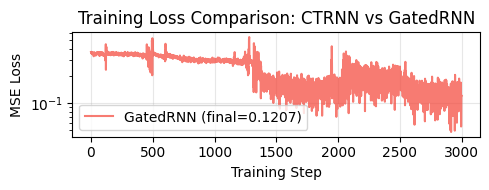

Loss comparison:
  CTRNN:     (loaded from disk)
  GatedRNN:  0.120670

Test MSE:
  CTRNN:     0.001495
  GatedRNN:  0.116783
  -> CTRNN is better by 0.115288


In [38]:
# ---- Compare training loss curves ----
fig, ax = plt.subplots(figsize=(5, 2))

if len(history) > 0:
    ctrnn_steps = [h["step"] for h in history]
    ctrnn_losses = [h["loss"] for h in history]
    ax.plot(ctrnn_steps, ctrnn_losses, linewidth=1.5, color='#2196F3',
            alpha=0.7, label=f'CTRNN (final={ctrnn_losses[-1]:.4f})')

if len(gated_history) > 0:
    gated_steps = [h["step"] for h in gated_history]
    gated_losses = [h["loss"] for h in gated_history]
    ax.plot(gated_steps, gated_losses, linewidth=1.5, color='#F44336',
            alpha=0.7, label=f'GatedRNN (final={gated_losses[-1]:.4f})')

ax.set_xlabel("Training Step")
ax.set_ylabel("MSE Loss")
ax.set_title("Training Loss Comparison: CTRNN vs GatedRNN")
ax.set_yscale("log")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
if len(history) > 0 or len(gated_history) > 0:
    plt.savefig(FIG_DIR / "training_loss_comparison.png", dpi=150)
plt.show()

print("Loss comparison:")
print(f"  CTRNN:     {ctrnn_losses[-1]:.6f}" if len(history) > 0 else "  CTRNN:     (loaded from disk)")
print(f"  GatedRNN:  {gated_losses[-1]:.6f}" if len(gated_history) > 0 else "  GatedRNN:  (loaded from disk)")

# Also evaluate on test set
gated_model.eval()
with torch.no_grad():
    gated_out = gated_model(test_inputs.to(device))
    gated_preds = gated_out.outputs.cpu().numpy()
gated_mse = np.mean((gated_preds - test_targets.numpy()) ** 2)
ctrnn_mse = np.mean((preds - test_targets.numpy()) ** 2)
print(f"\nTest MSE:")
print(f"  CTRNN:     {ctrnn_mse:.6f}")
print(f"  GatedRNN:  {gated_mse:.6f}")
if gated_mse < ctrnn_mse:
    print(f"  -> GatedRNN is better by {(ctrnn_mse - gated_mse):.6f}")
else:
    print(f"  -> CTRNN is better by {(gated_mse - ctrnn_mse):.6f}")

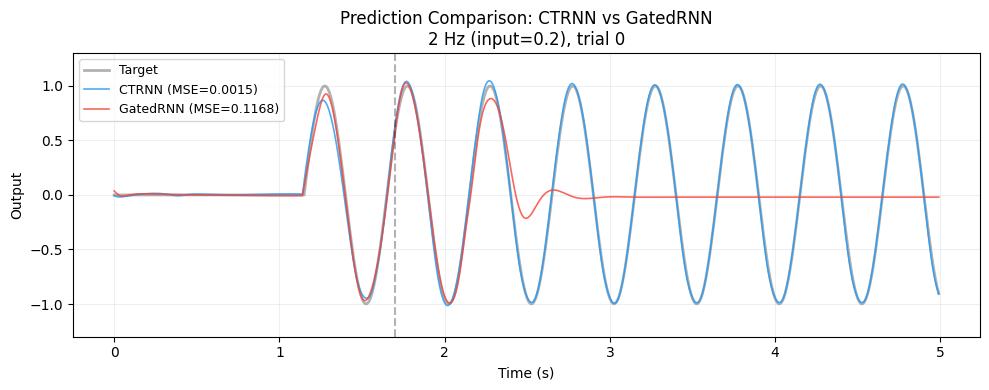

In [30]:
# ---- Visualize predictions from both models on a sample trial ----
trial_idx = np.where(test_conditions == 0)[0][0]  # First 2 Hz test trial
t = np.arange(N_POINTS) / FS
onset_s = test_onsets[trial_idx] / FS

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, test_targets[trial_idx, :, 0].numpy(),
        color='gray', lw=2, alpha=0.6, label='Target')
ax.plot(t, preds[trial_idx, :, 0],
        color='#2196F3', lw=1.2, alpha=0.8, label=f'CTRNN (MSE={ctrnn_mse:.4f})')
ax.plot(t, gated_preds[trial_idx, :, 0],
        color='#F44336', lw=1.2, alpha=0.8, label=f'GatedRNN (MSE={gated_mse:.4f})')
ax.axvline(x=onset_s, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Output')
ax.set_title(f'Prediction Comparison: CTRNN vs GatedRNN\n'
             f'{cond_names[0]}, trial {trial_idx}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_ylim(-1.3, 1.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "prediction_comparison.png", dpi=150)
plt.show()

---
## Summary: The Complete NeuralRNN Workflow

This notebook walked through **every step** of using NeuralRNN for a custom
research project:

| Step | What we did | Key API |
|------|-------------|---------|
| **1. Data** | Constructed 200-trial oscillatory dataset with 2 frequency conditions | `CustomDataset.from_arrays()` |
| **2. Import** | Wrapped data with train/test split, batch inspection | `dataset.sample_batch()` |
| **3. Model** | Built CTRNN via `AutoConfig`/`AutoModel` factory | `AutoConfig.for_model("ctrnn")` |
| **4. Training** | Loaded cached model or trained from scratch; explained Objective system | `AutoModel.from_pretrained()`, `Trainer`, `SupervisedObjective` |
| **5a. I/O** | Visualized model input + output predictions vs ground truth | `model(test_inputs)` |
| **5b. 3D PCA** | Reduced 64D → 3D, static + rotating + progression animations | `fit_pca(n=3)`, `viz.plot_trajectories_3d()` |
| **5c. Vector fields** | **Per-condition** PCA from onset, two vector field plots with correct input | `compute_vector_field()`, per-condition PCA |
| **5d. Fixed points** | **Per-condition** FP search with correct input, stability analysis | `find_fixed_points(backend="numeric")` |
| **5e. Eigenvalues** | Jacobian eigenvalue analysis — identified oscillatory modes | `linearize()`, `dominant_direction()` |
| **6. Custom model** | Defined GatedRNN from scratch, trained, compared with CTRNN | Direct class instantiation, `Trainer` |

### Key Design Decisions

1. **Two-method contract**: `recurrence()` + `readout()` = full framework access.
2. **Per-condition analysis**: For oscillatory tasks, separate PCA per condition
   from onset reveals the limit cycles that global PCA obscures.
3. **Direct class usage for custom models**: No `AutoModel`/`@register_model` needed
   for in-notebook custom architectures — just instantiate the class directly.
4. **Save-first-then-train**: Check for cached model before training to avoid
   redundant computation.

### Customizing for Your Own Research

1. **Replace the dataset** (Section 1) with your data loading
2. **Adjust the model** (Section 3) — change `latent_dim`, try different architectures
3. **Pick the right Objective** (Section 4) — regression vs classification vs DSR
4. **Run per-condition analysis** (Section 5c-d) — fit PCA per condition from the
   relevant time window
5. **Compare architectures** (Section 6) — define custom models and benchmark

### Further Reading


- `docs/ARCHITECTURE.md` — Full architecture documentation
- `docs/PORTING_GUIDE.md` — How to port a new model to the framework